# Models, selection, and final evaluation

This notebook trains, selects, and evaluates models for the MSME Financial Health Card.

**Evaluation rules**

- Use a fixed 70/15/15 train, validation, and test split.
- Fit preprocessing and models on training rows only.
- Select models and the eligibility threshold using validation rows only.
- Evaluate selected models once on held-out test rows.
- Never use `MSME_ID` or supplied outcome columns as predictors.


## 1. Environment and imports

Load the libraries and shared scoring helpers. The environment assertion prevents accidental execution outside the project conda environment.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

assert Path(sys.prefix).name == "ml", "Activate the ml conda environment first."

In [2]:
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from tqdm.auto import tqdm

In [3]:
from scoring import (
    ANOMALY_COLUMNS,
    CATEGORIES,
    RAW,
    SCORES,
    TARGETS,
    assess,
    credit_limit,
    log_numeric,
    make_features,
    predict_record,
)

In [4]:
ROOT = Path.cwd()
artifacts = ROOT / "artifacts"
reports = ROOT / "reports"
artifacts.mkdir(exist_ok=True)
reports.mkdir(exist_ok=True)

DATA_PATH = ROOT / "msme_synthetic_50k.csv"
df = pd.read_csv(DATA_PATH)
X = make_features(df)

# Leakage guard: identifiers and supplied outcomes must not enter model inputs.
assert not set(TARGETS + ["MSME_ID"]) & set(X)
print(f"Rows: {len(df):,}; model features: {X.shape[1]}")


Rows: 50,000; model features: 42


## 2. Fixed data partitions

Stratification preserves the joint customer-segment and risk-category mix. Saved indices make every later run reproducible.


In [5]:
indices = np.arange(len(df))
strata = df["Customer_Segment"] + "|" + df["Credit_Risk_Category"]

train, remainder = train_test_split(
    indices,
    test_size=0.30,
    stratify=strata,
    random_state=42,
)
valid, test = train_test_split(
    remainder,
    test_size=0.50,
    stratify=strata.iloc[remainder],
    random_state=42,
)

# Partition overlap would invalidate evaluation.
assert not (set(train) & set(valid))
assert not (set(train) & set(test))
assert not (set(valid) & set(test))

np.savez("local/splits.npz", train=train, validation=valid, test=test)
print({"train": len(train), "validation": len(valid), "test": len(test)})


{'train': 35000, 'validation': 7500, 'test': 7500}


In [6]:
# Targets used by the four supervised tasks.
ys = df[SCORES]
ye = df["Credit_Eligible"].eq("Yes").astype(int)
yr = df["Credit_Risk_Category"]
yl = np.log1p(df["Recommended_Credit_Limit_INR"])

# Compact inputs remove two highly redundant size measures.
feature_sets = {
    "full": list(X),
    "compact": [
        column
        for column in X
        if column not in ["Annual_Turnover_INR", "Monthly_GST_Sales_INR"]
    ],
}

candidates = {task: [] for task in ["scores", "eligibility", "risk", "limit"]}
validation_results = []


## 3. Candidate-model helpers

Linear models receive log transforms for nonnegative skewed inputs, missing-value indicators, scaling, and one-hot categories. CatBoost receives raw numeric and categorical inputs.


In [7]:
def build_linear_model(columns, estimator):
    """Build leakage-safe preprocessing followed by a linear estimator."""
    numeric = [column for column in columns if column not in CATEGORIES]
    preprocessing = ColumnTransformer(
        [
            (
                "numeric",
                make_pipeline(
                    SimpleImputer(add_indicator=True, keep_empty_features=True),
                    StandardScaler(),
                ),
                numeric,
            ),
            (
                "category",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                CATEGORIES,
            ),
        ],
        verbose_feature_names_out=True,
    )
    return make_pipeline(
        FunctionTransformer(log_numeric, feature_names_out="one-to-one"),
        preprocessing,
        estimator,
    )



class TqdmCatBoostCallback:
    """Update one tqdm bar after each CatBoost boosting iteration."""

    def __init__(self, progress_bar):
        self.progress_bar = progress_bar
        self.completed_iterations = 0

    def after_iteration(self, info):
        completed = int(info.iteration)
        self.progress_bar.update(completed - self.completed_iterations)
        self.completed_iterations = completed
        return True


In [8]:
def select_eligibility_threshold(record):
    """Choose the validation threshold with best macro-F1."""
    target = ye.iloc[valid]
    probability = predict_record(record, X.iloc[valid], True)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    scores = [
        f1_score(target, probability >= threshold, average="macro")
        for threshold in thresholds
    ]
    best_index = max(
        range(len(scores)),
        key=lambda index: (scores[index], -abs(thresholds[index] - 0.5)),
    )
    record["threshold"] = float(thresholds[best_index])
    return target, probability >= record["threshold"]

In [9]:
def evaluate_validation(task, record):
    """Calculate the task metric on validation rows and store it with the model."""
    prediction = predict_record(record, X.iloc[valid])
    result = {
        "task": task,
        "family": record["family"],
        "features": record["features"],
    }

    if task == "scores":
        errors = mean_absolute_error(
            ys.iloc[valid], np.clip(prediction, 0, 100), multioutput="raw_values"
        )
        result.update(metric=float(errors.mean()), per_score=errors.tolist())
    elif task == "limit":
        borrower_mask = ye.iloc[valid].to_numpy().astype(bool)
        actual_limit = df["Recommended_Credit_Limit_INR"].iloc[valid].to_numpy()
        predicted_limit = np.expm1(np.clip(prediction[borrower_mask], 0, 40))
        result["metric"] = float(
            mean_absolute_error(actual_limit[borrower_mask], predicted_limit)
        )
    else:
        if task == "eligibility":
            target, prediction = select_eligibility_threshold(record)
        else:
            target = yr.iloc[valid]
        result["metric"] = float(
            f1_score(target, np.asarray(prediction).reshape(-1), average="macro")
        )

    record["validation"] = result
    validation_results.append(result)
    print(result, flush=True)

## 4. Train candidate models

Compare Ridge or logistic regression with modest CatBoost models on full and compact feature sets. Positive credit-limit models train only on eligible businesses.

The outer `tqdm` bar tracks all 16 candidate models. Each CatBoost bar tracks boosting iterations up to 650, with early stopping after 50 validation rounds without improvement. Ridge has no epoch loop. Logistic regression uses `max_iter=100` as a convergence ceiling, not 100 mandatory epochs.

In [10]:
def build_catboost_model(task, parameters):
    """Create the task-specific CatBoost estimator and loss."""
    if task in ["scores", "limit"]:
        loss = "MultiRMSE" if task == "scores" else "RMSE"
        return CatBoostRegressor(loss_function=loss, **parameters)

    loss = "Logloss" if task == "eligibility" else "MultiClass"
    return CatBoostClassifier(loss_function=loss, **parameters)

In [11]:
def fit_candidate(task, target, family, columns, feature_set):
    """Fit one candidate with training-only preprocessing."""
    # Limit training uses eligible rows because eligibility separately gates zero.
    fit_rows = train[ye.iloc[train].to_numpy().astype(bool)] if task == "limit" else train
    validation_rows = valid[ye.iloc[valid].to_numpy().astype(bool)] if task == "limit" else valid

    # Linear max_iter is a convergence ceiling, not a fixed epoch count.
    if family == "linear":
        estimator = Ridge(alpha=10) if task in ["scores", "limit"] else LogisticRegression(C=1, max_iter=100)
        model = build_linear_model(columns, estimator)
        model.fit(X.iloc[fit_rows][columns], target.iloc[fit_rows])
        return model, fit_rows

    # Early stopping may finish before the 650-iteration ceiling.
    parameters = {
        "iterations": 650,
        "depth": 6,
        "learning_rate": 0.07,
        "random_seed": 42,
        "thread_count": 4,
        "verbose": False,
        "allow_writing_files": False,
    }
    model = build_catboost_model(task, parameters)
    epoch_bar = tqdm(
        total=parameters["iterations"],
        desc=f"CatBoost {feature_set}/{task}",
        unit="iteration",
        leave=False,
    )
    try:
        model.fit(
            X.iloc[fit_rows][columns],
            target.iloc[fit_rows],
            cat_features=CATEGORIES,
            eval_set=(X.iloc[validation_rows][columns], target.iloc[validation_rows]),
            early_stopping_rounds=50,
            callbacks=[TqdmCatBoostCallback(epoch_bar)],
        )
    finally:
        epoch_bar.close()
    return model, fit_rows

In [12]:
started = time.perf_counter()
training_tasks = [
    ("scores", ys),
    ("eligibility", ye),
    ("risk", yr),
    ("limit", yl),
]
total_candidates = len(feature_sets) * 2 * len(training_tasks)

# Outer progress shows candidate-model completion. CatBoost candidates also show
# their individual boosting iterations through the callback above.
with tqdm(total=total_candidates, desc="Candidate models", unit="model") as model_bar:
    for feature_set, columns in feature_sets.items():
        for family in ["linear", "catboost"]:
            for task, target in training_tasks:
                model_bar.set_postfix(
                    feature_set=feature_set,
                    family=family,
                    task=task,
                    refresh=True,
                )
                model, fit_rows = fit_candidate(
                    task, target, family, columns, feature_set
                )
                record = {
                    "family": family,
                    "features": feature_set,
                    "columns": columns,
                    "model": model,
                }

                # Linear SHAP needs the mean transformed training row as baseline.
                if family == "linear":
                    transformed = model[:-1].transform(X.iloc[fit_rows][columns])
                    record["background_mean"] = transformed.mean(axis=0)

                evaluate_validation(task, record)
                candidates[task].append(record)
                model_bar.update(1)

print("Training seconds:", round(time.perf_counter() - started, 2))

Candidate models:   0%|          | 0/16 [00:00<?, ?model/s]

{'task': 'scores', 'family': 'linear', 'features': 'full', 'metric': 0.5430607280874071, 'per_score': [1.854303382866641, 0.028690956733791823, 0.032044973625472026, 0.028044512114548524, 0.053309654040139424, 0.029842037947953756, 1.7751895792833037]}

{'task': 'eligibility', 'family': 'linear', 'features': 'full', 'metric': 0.9042325720693426}


{'task': 'risk', 'family': 'linear', 'features': 'full', 'metric': 0.8396756045118892}


{'task': 'limit', 'family': 'linear', 'features': 'full', 'metric': 163208.90523109317}


...

CatBoost compact/risk:   0%|          | 0/650 [00:00<?, ?iteration/s]

{'task': 'risk', 'family': 'catboost', 'features': 'compact', 'metric': 0.8394102114986605}


CatBoost compact/limit:   0%|          | 0/650 [00:00<?, ?iteration/s]

{'task': 'limit', 'family': 'catboost', 'features': 'compact', 'metric': 157208.34730988697}


Training seconds: 400.35


## 5. Baselines and model selection

Dummy models provide reference metrics. Selection favors simpler linear models when performance stays within the documented tolerance.


In [13]:
# Dummy references use training data only and do not compete for deployment.
dummy_scores = DummyRegressor().fit(np.zeros((len(train), 1)), ys.iloc[train])
dummy_metrics = {
    "scores_mae": mean_absolute_error(
        ys.iloc[valid],
        dummy_scores.predict(np.zeros((len(valid), 1))),
    )
}

for name, target in [("eligibility", ye), ("risk", yr)]:
    dummy = DummyClassifier(strategy="most_frequent").fit(
        np.zeros((len(train), 1)),
        target.iloc[train],
    )
    dummy_metrics[f"{name}_macro_f1"] = f1_score(
        target.iloc[valid],
        dummy.predict(np.zeros((len(valid), 1))),
        average="macro",
    )

print("Validation dummy metrics:", dummy_metrics)


Validation dummy metrics: {'scores_mae': 6.232689472761905, 'eligibility_macro_f1': 0.42638623326959846, 'risk_macro_f1': 0.205539672292416}


In [14]:
def choose_model(task, records):
    """Select the simplest candidate within the task-specific tolerance."""
    classification = task in ["eligibility", "risk"]
    best = (max if classification else min)(
        records,
        key=lambda record: record["validation"]["metric"],
    )

    def is_close(record):
        result = record["validation"]
        best_result = best["validation"]
        if classification:
            return result["metric"] >= best_result["metric"] - 0.01

        average_close = result["metric"] <= 1.01 * best_result["metric"]
        score_close = task != "scores" or np.all(
            np.array(result["per_score"])
            <= np.array(best_result["per_score"]) + 0.5
        )
        return average_close and score_close

    close_models = [record for record in records if is_close(record)]
    return min(
        close_models,
        key=lambda record: (
            record["family"] != "linear",
            record["features"] != "compact",
            -record["validation"]["metric"]
            if classification
            else record["validation"]["metric"],
        ),
    )


In [15]:
bundle = {
    task: choose_model(task, task_candidates)
    for task, task_candidates in candidates.items()
}
bundle["eligibility_threshold"] = bundle["eligibility"]["threshold"]

# IsolationForest flags the most unusual 2% of training profiles for review.
bundle["anomaly"] = make_pipeline(
    SimpleImputer(strategy="median", keep_empty_features=True),
    IsolationForest(
        n_estimators=200,
        max_samples=512,
        random_state=42,
        n_jobs=4,
    ),
)
bundle["anomaly"].fit(X.iloc[train][ANOMALY_COLUMNS])
training_anomaly_scores = -bundle["anomaly"].score_samples(
    X.iloc[train][ANOMALY_COLUMNS]
)
bundle["anomaly_threshold"] = float(np.quantile(training_anomaly_scores, 0.98))

bundle["feature_bounds"] = {
    column: [
        float(X.iloc[train][column].min()),
        float(X.iloc[train][column].max()),
    ]
    for column in X.select_dtypes("number")
}
bundle["version"] = "msme-v1-" + hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()[:10]


In [16]:
selection = {
    task: {
        "family": model["family"],
        "features": model["features"],
        "validation": model["validation"],
    }
    for task, model in bundle.items()
    if task in candidates
}

validation_table = pd.DataFrame(validation_results).drop(columns="per_score")
display(validation_table)
print("Selected:", {task: (item["family"], item["features"]) for task, item in selection.items()})

joblib.dump(bundle, artifacts / "models.joblib", compress=3)
(reports / "validation.json").write_text(
    json.dumps(
        {
            "candidates": validation_results,
            "selected": selection,
            "dummy": dummy_metrics,
        },
        indent=2,
    )
)


,task,family,features,metric
0,scores,linear,full,0.543061
1,eligibility,linear,full,0.904233
2,risk,linear,full,0.839676
3,limit,linear,full,163208.905231
4,scores,catboost,full,0.479949
5,eligibility,catboost,full,0.901741
6,risk,catboost,full,0.841167
7,limit,catboost,full,141422.840813
8,scores,linear,compact,0.543067
9,eligibility,linear,compact,0.904265


Selected: {'scores': ('catboost', 'compact'), 'eligibility': ('linear', 'compact'), 'risk': ('linear', 'compact'), 'limit': ('catboost', 'full')}


4315

## 6. Held-out test evaluation

Only selected models run below this point. No test result affects model or threshold selection.


In [17]:
test_features = X.iloc[test]
actual = df.iloc[test]

predicted_scores = np.clip(
    predict_record(bundle["scores"], test_features),
    0,
    100,
)
eligibility_probability = predict_record(
    bundle["eligibility"], test_features, True
)[:, 1]
predicted_eligible = eligibility_probability >= bundle["eligibility_threshold"]
predicted_risk = np.asarray(
    predict_record(bundle["risk"], test_features)
).reshape(-1)

predicted_positive_limit = credit_limit(bundle["limit"], test_features)
predicted_limit = np.where(
    predicted_eligible,
    predicted_positive_limit,
    0,
)

anomaly_score = -bundle["anomaly"].score_samples(
    test_features[ANOMALY_COLUMNS]
)
anomaly_flags = anomaly_score >= bundle["anomaly_threshold"]


In [18]:
score_metrics = pd.DataFrame(
    {
        "score": SCORES,
        "MAE": mean_absolute_error(
            ys.iloc[test], predicted_scores, multioutput="raw_values"
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                ys.iloc[test], predicted_scores, multioutput="raw_values"
            )
        ),
        "R2": r2_score(
            ys.iloc[test], predicted_scores, multioutput="raw_values"
        ),
    }
)
score_metrics.to_csv(reports / "test_scores.csv", index=False)
display(score_metrics.round(4))


,score,MAE,RMSE,R2
0,Business_Stability_Score,0.2516,0.3298,0.9983
1,Cashflow_Score,0.2739,0.3671,0.9976
2,Revenue_Consistency_Score,0.2564,0.3449,0.9982
3,Payment_Behaviour_Score,0.2330,0.3342,0.9967
4,Business_Growth_Score,0.3259,0.4337,0.9987
5,Compliance_Score,0.2336,0.3064,0.9981
6,Financial_Health_Score,1.7574,2.1993,0.8790


In [19]:
actual_eligible = ye.iloc[test].to_numpy().astype(bool)

metrics = {
    "eligibility_macro_f1": f1_score(
        ye.iloc[test], predicted_eligible, average="macro"
    ),
    "eligibility_roc_auc": roc_auc_score(
        ye.iloc[test], eligibility_probability
    ),
    "eligibility_pr_auc": average_precision_score(
        ye.iloc[test], eligibility_probability
    ),
    "risk_macro_f1": f1_score(
        yr.iloc[test], predicted_risk, average="macro"
    ),
    "eligibility_confusion_matrix": confusion_matrix(
        ye.iloc[test], predicted_eligible, labels=[0, 1]
    ).tolist(),
    "risk_labels": ["High", "Low", "Medium"],
    "risk_confusion_matrix": confusion_matrix(
        yr.iloc[test], predicted_risk, labels=["High", "Low", "Medium"]
    ).tolist(),
    "positive_limit_mae_inr": mean_absolute_error(
        actual["Recommended_Credit_Limit_INR"].to_numpy()[actual_eligible],
        predicted_positive_limit[actual_eligible],
    ),
    "positive_limit_log_rmse": float(
        np.sqrt(
            mean_squared_error(
                np.log1p(
                    actual["Recommended_Credit_Limit_INR"].to_numpy()[actual_eligible]
                ),
                np.log1p(predicted_positive_limit[actual_eligible]),
            )
        )
    ),
    "complete_limit_mae_inr": mean_absolute_error(
        actual["Recommended_Credit_Limit_INR"], predicted_limit
    ),
    "anomaly_review_rate": float(anomaly_flags.mean()),
    "test_rows": len(test),
    "eligibility_threshold": bundle["eligibility_threshold"],
}

display(pd.Series({key: value for key, value in metrics.items() if not isinstance(value, list)}))
(reports / "test_metrics.json").write_text(json.dumps(metrics, indent=2))


eligibility_macro_f1            0.902248
eligibility_roc_auc             0.978941
eligibility_pr_auc              0.992742
risk_macro_f1                   0.837703
positive_limit_mae_inr     143697.080704
positive_limit_log_rmse         0.180241
complete_limit_mae_inr     149943.623263
anomaly_review_rate             0.021200
test_rows                    7500.000000
eligibility_threshold           0.540000
dtype: float64

743

In [20]:
# Row-level predictions stay local and are excluded from the public repository.
test_predictions = pd.DataFrame(
    {
        "MSME_ID": actual["MSME_ID"].to_numpy(),
        "actual_health": actual["Financial_Health_Score"].to_numpy(),
        "predicted_health": predicted_scores[:, 6],
        "actual_eligible": actual_eligible,
        "predicted_eligible": predicted_eligible,
        "actual_risk": actual["Credit_Risk_Category"].to_numpy(),
        "predicted_risk": predicted_risk,
        "actual_limit": actual["Recommended_Credit_Limit_INR"].to_numpy(),
        "predicted_limit": predicted_limit,
        "anomaly": anomaly_flags,
    }
)
test_predictions.to_csv("local/test_predictions.csv", index=False)


## 7. Subgroup and tail checks

Report performance and anomaly-review rates across customer segments, industries, loan status, and turnover bands. Differences are audited, not automatically corrected.


In [21]:
turnover_boundaries = df["Annual_Turnover_INR"].iloc[train].quantile(
    [0.25, 0.50, 0.75, 0.99]
).to_numpy()

groups = {
    "Customer_Segment": actual["Customer_Segment"].to_numpy(),
    "Industry": actual["Industry"].to_numpy(),
    "Has_Existing_Loan": actual["Has_Existing_Loan"].to_numpy(),
    "Turnover_Band": pd.cut(
        actual["Annual_Turnover_INR"],
        [-np.inf, *turnover_boundaries, np.inf],
        labels=["Q1", "Q2", "Q3", "P75-P99", "Above training P99"],
    ).astype(str).to_numpy(),
}


In [22]:
def evaluate_subgroup(dimension, value, values):
    """Calculate held-out metrics for one business subgroup."""
    mask = values == value
    row = {
        "dimension": dimension,
        "group": value,
        "count": int(mask.sum()),
        "health_mae": mean_absolute_error(
            actual["Financial_Health_Score"].to_numpy()[mask], predicted_scores[mask, 6]
        ),
        "mean_score_mae": mean_absolute_error(actual_score_array[mask], predicted_scores[mask]),
        "eligibility_macro_f1": f1_score(
            actual_eligible[mask], predicted_eligible[mask], average="macro", zero_division=0
        ),
        "risk_macro_f1": f1_score(
            actual_risk[mask], predicted_risk[mask], average="macro", zero_division=0
        ),
        "limit_mae_inr": mean_absolute_error(actual_limit[mask], predicted_limit[mask]),
        "anomaly_rate": float(anomaly_flags[mask].mean()),
    }
    for index, name in enumerate(SCORES):
        row[f"{name}_MAE"] = mean_absolute_error(
            actual_score_array[mask, index], predicted_scores[mask, index]
        )
    return row

In [23]:
actual_score_array = ys.iloc[test].to_numpy()
actual_risk = actual["Credit_Risk_Category"].to_numpy()
actual_limit = actual["Recommended_Credit_Limit_INR"].to_numpy()

# Materialize groups so tqdm can display an exact total.
subgroup_slices = [
    (dimension, value, values)
    for dimension, values in groups.items()
    for value in sorted(set(values))
]

subgroup_rows = [
    evaluate_subgroup(dimension, value, values)
    for dimension, value, values in tqdm(
        subgroup_slices, desc="Subgroup checks", unit="group"
    )
]
subgroup_metrics = pd.DataFrame(subgroup_rows)
subgroup_metrics.to_csv(reports / "subgroup_metrics.csv", index=False)
display(subgroup_metrics.iloc[:, :8].round(3))

Subgroup checks:   0%|          | 0/20 [00:00<?, ?group/s]

,dimension,group,count,health_mae,mean_score_mae,eligibility_macro_f1,risk_macro_f1,limit_mae_inr
0,Customer_Segment,Existing-to-Credit,2094,1.755,0.479,0.901,0.840,147554.218
1,Customer_Segment,NTB,2246,1.736,0.472,0.899,0.839,148665.489
2,Customer_Segment,NTC,3160,1.774,0.477,0.905,0.834,152435.428
3,Industry,Construction,472,1.722,0.468,0.917,0.848,190774.203
4,Industry,Food & Beverage,787,1.768,0.474,0.892,0.845,95619.415
5,Industry,Healthcare,379,1.808,0.478,0.864,0.800,161477.350
6,Industry,IT & Digital,352,1.793,0.480,0.902,0.846,84488.681
7,Industry,Logistics,502,1.688,0.466,0.903,0.838,141407.659
8,Industry,Manufacturing,948,1.737,0.476,0.909,0.841,212140.538
9,Industry,Retail,1317,1.756,0.480,0.914,0.851,133678.170


## 8. Visual evaluation

Compare predicted and supplied synthetic health scores, then show held-out error for each score dimension.


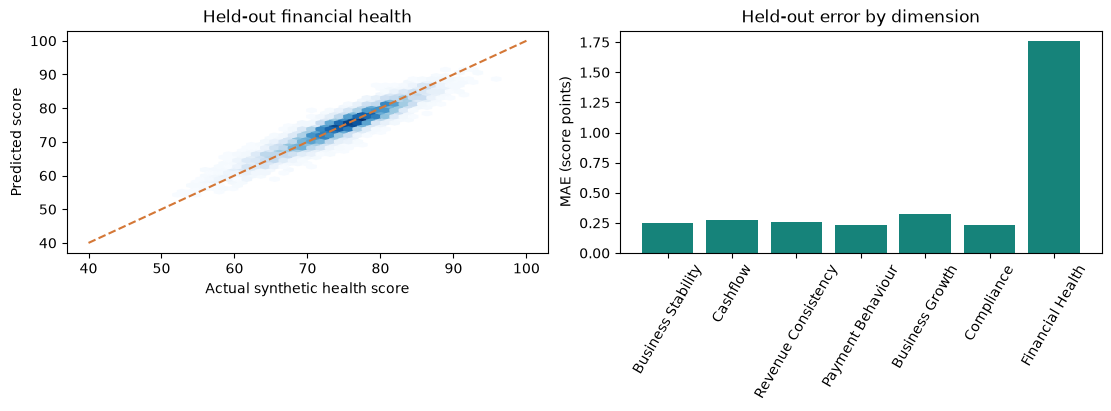

In [24]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

axes[0].hexbin(
    actual["Financial_Health_Score"],
    predicted_scores[:, 6],
    gridsize=35,
    mincnt=1,
    cmap="Blues",
)
axes[0].plot([40, 100], [40, 100], "--", color="#d47736")
axes[0].set(
    xlabel="Actual synthetic health score",
    ylabel="Predicted score",
    title="Held-out financial health",
)

score_labels = score_metrics["score"].str.replace("_Score", "").str.replace("_", " ")
axes[1].bar(score_labels, score_metrics["MAE"], color="#16837a")
axes[1].tick_params(axis="x", rotation=60)
axes[1].set(
    ylabel="MAE (score points)",
    title="Held-out error by dimension",
)

figure.savefig(reports / "model_results.png", dpi=150)
plt.show()


## 9. Explanation and latency checks

Check SHAP reconstruction on one held-out business per customer segment. Measure warm scoring latency without explanation generation.


In [25]:
# Held-out input rows stay local; public reports contain aggregate checks only.
explanation_checks = []
for segment in tqdm(
    ["NTC", "NTB", "Existing-to-Credit"],
    desc="Explanation checks",
    unit="segment",
):
    row = actual.loc[
        actual["Customer_Segment"].eq(segment),
        ["MSME_ID"] + RAW,
    ].iloc[0].astype(object)
    payload = row.where(row.notna(), None).to_dict()

    started = time.perf_counter()
    card = assess(payload, bundle)
    explanation_checks.append(
        {
            "segment": segment,
            "explanation_seconds": time.perf_counter() - started,
            "health_reconstruction_error": abs(
                card["explanations"]["health"]["raw_prediction"]
                - card["explanations"]["health"]["reconstructed"]
            ),
        }
    )

display(pd.DataFrame(explanation_checks))


Explanation checks:   0%|          | 0/3 [00:00<?, ?segment/s]

,segment,explanation_seconds,health_reconstruction_error
0,NTC,0.559866,2.842171e-14
1,NTB,0.058641,0.000000e+00
2,Existing-to-Credit,0.056086,0.000000e+00


In [26]:
latencies = []
for _ in tqdm(range(20), desc="Latency checks", unit="assessment"):
    started = time.perf_counter()
    assess(payload, bundle, explain=False)
    latencies.append(time.perf_counter() - started)

latency_report = {
    "warm_scoring_p50_ms": 1000 * float(np.median(latencies)),
    "warm_scoring_p95_ms": 1000 * float(np.quantile(latencies, 0.95)),
    "explanation_cases": explanation_checks,
    "platform": platform.platform(),
    "python": sys.version.split()[0],
}
(reports / "latency.json").write_text(json.dumps(latency_report, indent=2))


Latency checks:   0%|          | 0/20 [00:00<?, ?assessment/s]

608

## 10. Save reproducibility metadata

The manifest records data identity, split policy, selected models, allowed inputs, and known limitations.


In [27]:
manifest = {
    "version": bundle["version"],
    "dataset_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "split": {
        "train": len(train),
        "validation": len(valid),
        "test": len(test),
        "seed": 42,
        "stratify": "Customer_Segment + Credit_Risk_Category",
    },
    "selected": selection,
    "input_columns": RAW,
    "excluded_targets": TARGETS,
    "limitations": [
        "Synthetic labels only",
        "No observed defaults",
        "No dated histories",
        "No anomaly labels",
    ],
    "feature_bounds_source": "training partition",
    "anomaly_threshold_source": "98th percentile training anomaly score",
}
(artifacts / "manifest.json").write_text(json.dumps(manifest, indent=2))

print("Artifacts, metrics, and reconstruction checks saved. No test-driven tuning performed.")


Artifacts, metrics, and reconstruction checks saved. No test-driven tuning performed.


## Interpretation and limits

The seven-score model learns supplied synthetic labels. Strong performance can reflect simple generator rules, not real underwriting skill. Eligibility probabilities reproduce a synthetic eligibility label and are not calibrated probabilities of repayment or approval.

Credit limits use log targets with an eligibility gate. Large-business rupee errors must be reviewed separately. Anomaly flags indicate uncommon profiles, not verified fraud or incorrect records. Subgroup metrics are diagnostic checks; synthetic data cannot establish production fairness.

Serving uses frozen models fitted on the training partition and selected on validation results. No full-data refit changes the evaluated model. Source data and row-level test predictions stay outside the public repository.
